In [148]:
# Required Packages

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import cumfreq, ks_2samp, linregress
import bisect

In [189]:
WL_FILE_PATH = 'D:/py_scripts/data_sample/WL.csv'
CALENDAR_YEAR = True
key = 'CloudFree'

Reading the water level data and do some preprocessing and formatting

In [190]:
water_level = pd.read_csv(WL_FILE_PATH)
# water_level['WL'] =water_level.iloc[:,3:5].WL(axis=1)

water_level['Date'] = pd.to_datetime(water_level['Date'])
water_level['Year'] = pd.DatetimeIndex(water_level['Date']).year
water_level['Month'] = pd.DatetimeIndex(water_level['Date']).month
water_level = water_level[water_level['Year']>=2012]
# water_level['Year-Month'] =  water_level['Year'].astype(str) + '-' + water_level['Month'].astype(str) #str(water_level['Year'])+'-'+str(water_level['Month'])

water_level_v1 = pd.DataFrame()
HYears =[]
if CALENDAR_YEAR == False:
    # If hydrological year is different from calendar year, then here we have to mention start and end of each hydrological year
    start =pd.DatetimeIndex (['2012-07-01','2013-07-01','2014-07-01','2015-07-01','2016-07-01','2017-07-01','2018-07-01','2019-06-01','2020-07-01','2021-07-01','2022-07-01'])
    end = pd.DatetimeIndex(['2013-06-30','2014-06-30','2015-06-30','2016-06-30','2017-06-30','2018-06-30','2019-06-30','2020-05-30','2021-06-30','2022-06-30','2023-06-30'])

    #water_level.describe()
    for i in range(len(start)):
        temp = water_level[(water_level['Date']>=start[i]) & (water_level['Date']<= end[i])].copy()
        temp['HYear'] = str(pd.to_datetime(start[i]).year) + '/' + str(pd.to_datetime(end[i]).year)
        water_level_v1 = pd.concat([water_level_v1,temp], axis = 0)
        
    for i in range(len(start)):
        #temp = water_level[(water_level['Date']>=start[i]) & (water_level['Date']<= end[i])] 
        h = str(pd.to_datetime(start[i]).year) + '/' + str(pd.to_datetime(end[i]).year)
        HYears.append(h)
    
else:
    water_level_v1 = water_level
    water_level['HYear'] = water_level['Year']
    HYears = water_level['Year']

water_level_v1


,Date,WL,Year,Month,HYear
0,2019-01-01,24.343977,2019,1,2019
1,2019-01-02,24.488068,2019,1,2019
2,2019-01-03,24.873636,2019,1,2019
3,2019-01-04,25.521705,2019,1,2019
4,2019-01-05,26.008750,2019,1,2019
...,...,...,...,...,...
1810,2023-12-16,4.093750,2023,12,2023
1811,2023-12-17,3.778409,2023,12,2023
1812,2023-12-18,3.446023,2023,12,2023
1813,2023-12-19,3.343750,2023,12,2023


A class object to perform linear interpolation: to find exceedance probability for particular water level

In [191]:
class Interpolation:
    def __init__(self, depth_bins, bins_ep):
        '''
        Initialize the interpolation with depth bins and their exceedance probabilities.
        Args:
        depth_bins: Bins generated from histogram (sorted array).
        bins_ep: Exceedance probability of the bins.
        '''
        # Ensure the arrays are sorted by depth bins
        sorted_indices = np.argsort(depth_bins)
        self.depth_bins = np.array(depth_bins)[sorted_indices]
        self.bins_ep = np.array(bins_ep)[sorted_indices]

    def find_enclosing_indices(self, ref):
        '''
        Find indices of the depth bins that enclose the reference depth.
        Args:
        ref: Reference depth to find enclosing bins for.
        Returns:
        A tuple of indices for the enclosing bins.
        '''
        pos = bisect.bisect_right(self.depth_bins, ref)
        lower_idx = max(0, pos-1)
        upper_idx = min(len(self.depth_bins) - 1, pos)
        return (lower_idx, upper_idx)

    def interpolate(self, ref):
        '''
        Interpolate to find the exceedance probability at the reference depth.
        Args:
        ref: Reference depth for which exceedance probability is estimated.
        Returns:
        Interpolated exceedance probability.
        '''
        lower_idx, upper_idx = self.find_enclosing_indices(ref)
       
        lower_depth, upper_depth = self.depth_bins[lower_idx], self.depth_bins[upper_idx]
        lower_ep, upper_ep = self.bins_ep[lower_idx], self.bins_ep[upper_idx]
        
        # Handle the case where the reference depth matches one of the boundaries exactly
        if lower_depth == upper_depth:
            return lower_ep
        
        # Linear interpolation
        interpolated_ep = (lower_ep + (upper_ep - lower_ep) * (ref - lower_depth) / (upper_depth - lower_depth))
        
        # Clamping the result between 0 and 1
        interpolated_ep = max(0, min(1, interpolated_ep))
        return interpolated_ep



FREQUENCY ANALYSIS OF WATER LEVEL

In [192]:

def FreqAnalysis(year_yth, year, water_levels, is_exceedance = False):
    exceedance_all_year = pd.DataFrame(columns = water_levels)
    # print(year_yth)
    year_yth = year_yth.iloc[:,1:2]
    
    year_yth = year_yth.sort_values(by = 'WL', ascending = False, axis = 0)
    
    year_yth['rank'] = np.arange(1,year_yth.shape[0] + 1)
    year_yth['exceedance'] = year_yth['rank']/(year_yth.shape[0] + 1)
    
    bins_count = year_yth['WL'].values
    exceedance = year_yth['exceedance'].values
    cdf = 1- exceedance
    
    # plotting PDF and CDF 
    if is_exceedance:
        plt.plot(bins_count[:],exceedance, label=year) 
        plt.xlabel('water level (masl)')
        plt.ylabel('exceedance  proability')
        plt.legend() 
    else:
        plt.plot(bins_count[:],cdf, label=year) 
        plt.xlabel('water level (m PWD)')
        plt.ylabel('cdf')
        plt.legend()
    
    exceedance_prob = []

    inter = Interpolation(depth_bins = bins_count, bins_ep = exceedance)
    for element in water_levels:
        estimated_prob = inter.interpolate(element)
        exceedance_prob.append(estimated_prob)

    exceedance_all_year.loc[len(exceedance_all_year)] = exceedance_prob
    
    return exceedance_all_year

Sampling the images desired period to reduce skewness

In [193]:
def sampling(water_level, num_of_samples, start_date, end_date):
    # Subseting the images dates within the desired period
    to_be_resampled = water_level[( water_level['Date'] >= start_date ) & ( water_level['Date'] <= end_date )]
    remaining = water_level[~(( water_level['Date'] >= start_date ) & ( water_level['Date'] <= end_date ))]
  
    to_be_resampled_dates = pd.DataFrame(to_be_resampled['Date'])

    if num_of_samples > to_be_resampled.shape[0]:
        resampled_merged = water_level
    else:
        # Uniform sampling 
        indices = np.linspace(0, to_be_resampled_dates.shape[0]-1, num= num_of_samples)
        uniform_sample = to_be_resampled.iloc[indices]
        resampled_merged = pd.concat([remaining,uniform_sample],axis=0)
    return resampled_merged
 
    

Finding Optimum number of images to be selected from the available low flow period images. Optimum no. of sample is that no. which will make sure the parent cdf and sampled cdf are as close as possible. Kolmogorov-Smirnov test has been used to find the optimum value. This test is commonly use to check if two datasets have similar cdf.

In [194]:
def OptimumNumberOfSamples(parent_wl, child_wl, start_date, end_date):
    to_be_resampled = child_wl[(child_wl['Date'] >= start_date) & (child_wl['Date'] <= end_date)]
    print(f'No. of images in sampling period: {to_be_resampled.shape[0]}')
    optimization_space = np.arange(1,to_be_resampled.shape[0],1)
    KS_STAT = []
    P_VALUE = []
    
    for n in optimization_space:
        resampled_wl = sampling(child_wl, n,start_date, end_date)
        
        cfreq_child = cumfreq(np.array(resampled_wl['WL']),numbins = resampled_wl.shape[0])
        cdf_child = cfreq_child.cumcount/resampled_wl.shape[0]
        
        cfreq_parent = cumfreq(np.array(parent_wl['WL']), numbins = parent_wl.shape[0])
        cdf_parent = cfreq_parent.cumcount/parent_wl.shape[0]
        # print(cdf_parent.shape, cdf_child.shape)
        ks_stat, p_val = ks_2samp(cdf_parent, cdf_child)
        KS_STAT.append(ks_stat)
        P_VALUE.append(p_val)
        # print(f'KS Stat:{ks_stat} P Value:{p_val}')
    optimum_no_of_sample = optimization_space[np.argmin(KS_STAT)]
    p_value_of_optimum = P_VALUE[np.argmin(KS_STAT)]
    min_ks_stat = min(KS_STAT)
    return (optimum_no_of_sample, min_ks_stat, p_value_of_optimum)
    # print(KS_STAT,np.argmin(KS_STAT),optimization_space[np.argmin(KS_STAT)])
        
    

Visualization and Analysis of Temporal Image Distribution and correcting the skewness

In [195]:

ls8_id = 'LC08'
s1a_id = 'S1A'
s1b_id = 'S1B'
s2_id = 'T45QYG'

def which_satellite(system_index):
    if ls8_id in system_index:
        return 'Landsat 8'
    elif s1a_id in system_index:
        return 'Sentinel 1'
    elif s1b_id in system_index:
        return 'Sentinel 1'
    else:
        return 'Sentinel 2'

def ImageDistribution(water_level_df = water_level_v1, 
                      dates_pth = None,
                      area_pth = None,
                      yoi = None, 
                      min_wl = None,max_wl = None, step = None,
                      resample = False, 
                      start_date = None, 
                      end_date = None, 
                      remove_outliers = False, 
                      outlier_tol_per = 10, 
                      is_exceedance = False, 
                      AreaWL = False,
                      linear = False):
    
    if CALENDAR_YEAR == False:
        year1 = str.split(yoi,sep='/')[0]
        year2 = str.split(yoi, sep='/')[1]
        # pth =  "D:/py_scripts/data_sample/CloudFree_ImagesDate_2019_2020.csv" #"ImagesDates/indira_sagar_" + key + "_ImagesDate_" + year1 + '_' + year2 + '_v1.csv'
    else:
        year1 = yoi
        year2 = yoi
        # pth = "D:/py_scripts/data_sample/intake_site_CloudFree_ImagesDate_2020_2020_v0.csv"
    
    image_dates = pd.read_csv(dates_pth)
     
    if AreaWL:
        images_area = pd.read_csv(area_pth).iloc[:,1:3]
        images_area['Date'] = pd.to_datetime(images_area['Date'])
    
    index_dates = image_dates.copy()
    index_dates.columns = ['system:index','Date','geo']
    index_dates['Satellite'] = index_dates['system:index'].apply(which_satellite)
    index_dates['Date'] = pd.to_datetime(index_dates['Date'	])
  
    image_dates = image_dates.iloc[:,1:2].values.flatten()
    image_dates = pd.to_datetime(image_dates)
    
    # Water levels corresponsing to available images dates
    sub_water_level = water_level_df[water_level_df["Date"].isin(image_dates)]
    
    sub_water_level = pd.merge(left = sub_water_level, right = index_dates, how = 'left',on = 'Date')
    if AreaWL:
        sub_water_level = pd.merge(left= sub_water_level, right= images_area,how='left',on='Date')
    
    # Water level series of whole year
    all_water_level = water_level_df[water_level_df['HYear'] == yoi]

    # Performing resampling to reduce skewness
    if resample:
        optimum_no_of_images,ks_stat, p_stat = OptimumNumberOfSamples(parent_wl = all_water_level,child_wl = sub_water_level, start_date= start_date, end_date = end_date)
        print(f'Optimum no. of low flow image samples:{optimum_no_of_images}\n KS-Stat: {ks_stat} \n P-value:{p_stat}')
        resampled_water_level = sampling(sub_water_level,num_of_samples= optimum_no_of_images, start_date = start_date, end_date = end_date)
    else:
        resampled_water_level = sub_water_level
       

    ep1 = FreqAnalysis(water_levels= np.arange(min_wl,max_wl,step), year_yth = all_water_level,is_exceedance = is_exceedance, year =  'all')
    ep2 = FreqAnalysis(water_levels= np.arange(min_wl,max_wl,step), year_yth = sub_water_level,is_exceedance = is_exceedance, year =  'images')
    if resample:
        ep3 = FreqAnalysis(water_levels= np.arange(min_wl,max_wl,step), year_yth =  resampled_water_level,is_exceedance = is_exceedance, year ='resampled')
        # count_resampled_dry_images = resampled_water_level[resampled_water_level['WL']<low_threshold].shape[0]
        # print(pd.DataFrame(ep3))
        
        if linear:
            x1 = ep3.columns[0]
            y1 = ep3.iloc[:1,:].values.flatten()[0]
            x2 = ep3.columns[-1]
            y2 = ep3.iloc[:1,:].values.flatten()[-1]
            slope = (y2-y1)/(x2-x1)
            linear_wop =[(slope * (x-x1)) + y1 for x in ep3.columns]
            linear_wop = pd.DataFrame([linear_wop], columns= ep3.columns)
            ep3 = pd.concat([ep3,linear_wop]).T
            ep3.columns = ['excd prob water', 'linear wop']
            
        pd.DataFrame(ep3).T.to_csv(f'wl_exceedance_probability_{year1}_{year2}__wop_linear.csv')
    else:
        count_resampled_dry_images = 'NA'

    total_images = sub_water_level.shape[0]
    # count_dry_images = sub_water_level[sub_water_level['WL'] < low_threshold].shape[0]
    # count_wet_images = sub_water_level[sub_water_level['WL'] > high_threshold].shape[0]
    # print(resampled_water_level)


    satellite_colors = {
        'Landsat 8': 'black',  
        'Sentinel 1': 'black',  
        'Sentinel 2': 'black'  
        }
    fig = plt.figure(figsize=(6.4,4.8))
    plt.scatter(sub_water_level['Date'],sub_water_level['WL'],c='red',marker= '*',s=60, label = 'image available', zorder = 2)
    
    if resample:
        plt.scatter(resampled_water_level['Date'],resampled_water_level['WL'], c='black',marker= '*',s =20, label = 'resampled',zorder =3)
        # sns.scatterplot(data= resampled_water_level, x = 'Date', y = 'WL',s= 15, hue = 'Satellite',palette = satellite_colors, zorder = 3)
    
    plt.plot(all_water_level['Date'],all_water_level['WL'], label= 'water level',zorder = 1)
    plt.text(0.8,0.7, f'Total images: {total_images}',ha = 'center',va = 'center', transform = plt.gca().transAxes, fontsize = 7)
    plt.xlabel('date')
    plt.ylabel('water level (masl)')
    plt.legend(loc='upper right', fontsize = 7)
    plt.savefig(f'{key}_image_distribution_2019_2020.png',dpi = 600)
    
    if AreaWL:
        fig1 = plt.figure(figsize= (12,6))
        slope, intercept, r_value, p_value, std_err = linregress(resampled_water_level['WL'], resampled_water_level['Area'])
        print(f"----area = {slope}.wl + {intercept}--------")
        if remove_outliers:
            resampled_water_level['pred_area'] = resampled_water_level['WL'] * slope + intercept
            
            resampled_water_level['deviation'] = abs(resampled_water_level['Area']- resampled_water_level['pred_area']) *100 / (resampled_water_level['pred_area'])
            resampled_water_level = resampled_water_level[resampled_water_level['deviation']< outlier_tol_per]
            slope, intercept, r_value, p_value, std_err = linregress(resampled_water_level['WL'], resampled_water_level['Area'])
        sns.regplot(data= resampled_water_level, x='WL',y = 'Area', scatter_kws={ 's' : 15}, ci = None, line_kws={'color': 'grey', 'linestyle':'--','linewidth': 1})
        plt.xlabel('water level (m)')
        plt.ylabel('area (sq. km)')
        
        # Annotate the plot with the R^2 value
        plt.text(x=max(resampled_water_level['WL']), y=min(resampled_water_level['Area']), s=f'$R^2$: {r_value**2:.2f} \n P-value: {p_value.__round__(4)}', 
                horizontalalignment='right', verticalalignment='bottom', fontsize=12, color='green')

    return resampled_water_level
    




No. of images in sampling period: 65
Optimum no. of low flow image samples:40
 KS-Stat: 0.12068159037754761 
 P-value:0.25886257683227387
----area = 29.80492487753542.wl + -22.16648296751694--------


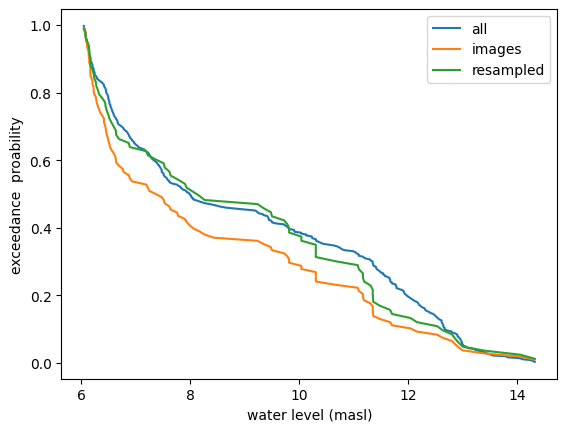

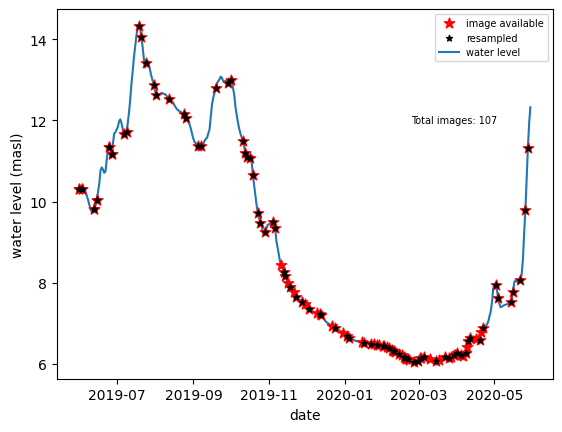

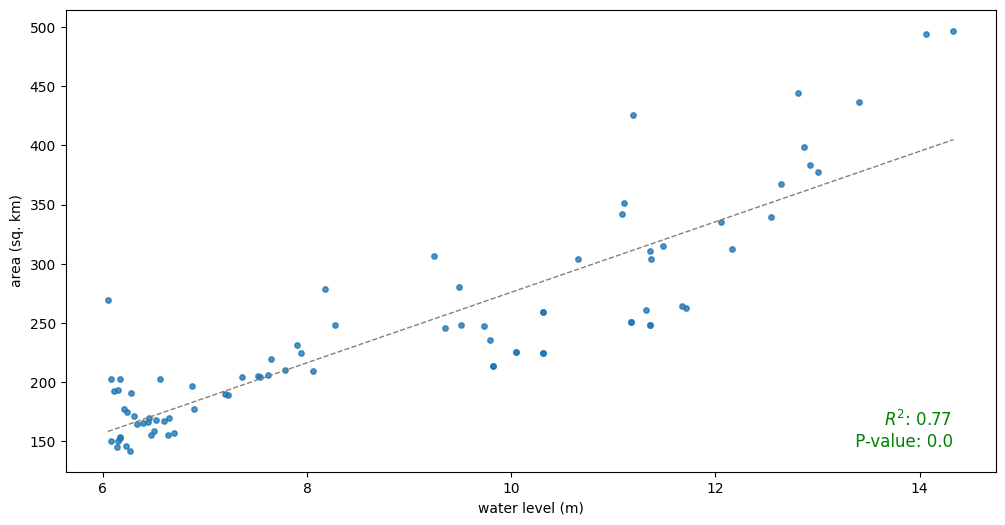

In [188]:

resampled_2019_2020 = ImageDistribution(yoi = '2019/2020', 
                                        dates_pth = "D:/py_scripts/data_sample/CloudFree_ImagesDate_2019_2020.csv",
                                        area_pth = 'D:/py_scripts/data_sample/CloudFree_WaterSurfaceArea_2019_2020.csv',
                                        min_wl = 5,
                                        max_wl = 14,
                                        step = 0.5,
                                        resample = True, 
                                        start_date = pd.to_datetime('2019-11-01'),
                                        end_date = pd.to_datetime('2020-05-01'),
                                        AreaWL = True, 
                                        remove_outliers = False, 
                                        outlier_tol_per = 10, 
                                        is_exceedance = True, 
                                        linear = True)  # cloud-free::35 ;; cloud-inferred:: 55

# resampled_2019_2020.sort_values(by = 'Date').to_csv('Resampled_'+key+'_ImagesDate_2019_2020_outliers_removed.csv',index= False)

No. of images in sampling period: 15
Optimum no. of low flow image samples:14
 KS-Stat: 0.2878495660559306 
 P-value:1.5028338730179645e-05


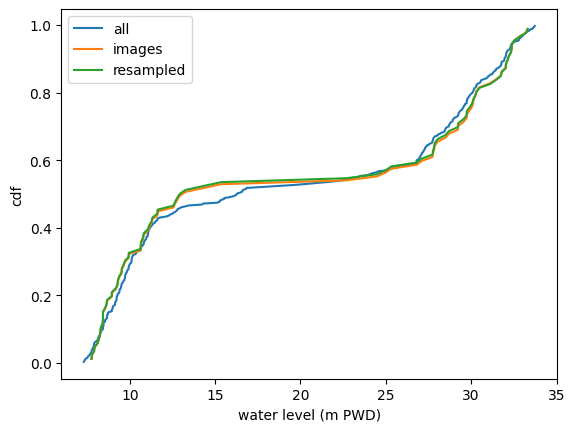

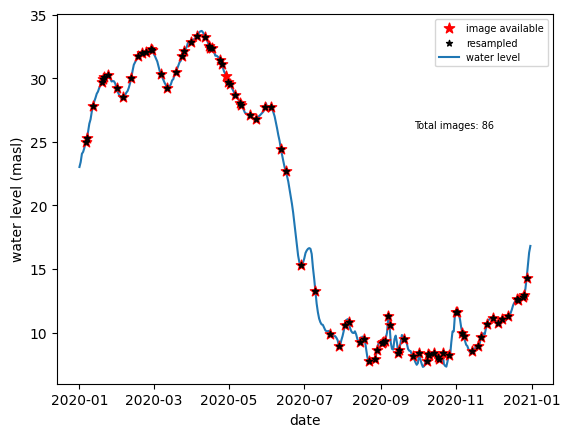

In [203]:

resampled_2019_2020 = ImageDistribution(yoi = 2020, 
                                        dates_pth = "D:/py_scripts/data_sample/intake_site_CloudFree_ImagesDate_2020_2020_v0.csv",
                                        area_pth = 'D:/py_scripts/data_sample/CloudFree_WaterSurfaceArea_2019_2020.csv',
                                        min_wl = 9,
                                        max_wl = 32,
                                        step = 0.5,
                                        resample = True, 
                                        start_date = pd.to_datetime('2020-03-01'),
                                        end_date = pd.to_datetime('2020-05-01'),
                                        AreaWL = False, 
                                        remove_outliers = False, 
                                        outlier_tol_per = 10, 
                                        is_exceedance = False, 
                                        linear = False)  # cloud-free::35 ;; cloud-inferred:: 55

# resampled_2019_2020.sort_values(by = 'Date').to_csv('Resampled_'+key+'_ImagesDate_2019_2020_outliers_removed.csv',index= False)